In [1]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

from pymargins import Margins

rng = np.random.default_rng(3)
n = 4000
df = pd.DataFrame({
    "age": rng.integers(18, 70, n),
    "income": rng.uniform(20, 200, n),
})
# Three-category outcome: bus / car / bike
util_car = 0.05 * df["age"] + 0.01 * df["income"]
util_bike = 0.02 * (60 - df["age"]) + rng.normal(0, 1, n)
util_bus = np.zeros(n)
util = np.column_stack([util_bus, util_car, util_bike])
util += rng.gumbel(size=util.shape)
df["mode"] = util.argmax(1)  # 0=bus, 1=car, 2=bike

# Note: pymargins uses integer outcome indices for MNLogit.

fit = smf.mnlogit("mode ~ age + income", data=df).fit()

Optimization terminated successfully.
         Current function value: 0.427064
         Iterations 7


In [2]:
m = Margins.linear_scale(fit, at="overall")
preds = m.predict(atexog={"age": [25, 45, 65]})
print(preds.summary())

               Margins Result (delta, level=0.95)               
            estimate  std err         z  P>|z|  [95% Conf. Int.]
----------------------------------------------------------------
age=25 (0)    0.0816   0.0070   11.6543  0.000    0.0679, 0.0954
age=25 (1)    0.7428   0.0111   66.7689  0.000    0.7210, 0.7646
age=25 (2)    0.1756   0.0098   17.9626  0.000    0.1564, 0.1947
age=45 (0)    0.0322   0.0032    9.9477  0.000    0.0258, 0.0385
age=45 (1)    0.9062   0.0053  169.4000  0.000    0.8957, 0.9167
age=45 (2)    0.0616   0.0045   13.7811  0.000    0.0529, 0.0704
age=65 (0)    0.0108   0.0022    4.8803  0.000    0.0065, 0.0152
age=65 (1)    0.9705   0.0036  267.4247  0.000    0.9634, 0.9776
age=65 (2)    0.0186   0.0028    6.5870  0.000    0.0131, 0.0242

n = 4000
κ: max=0.202
Delta-vs-sim disagreement: 12.292%


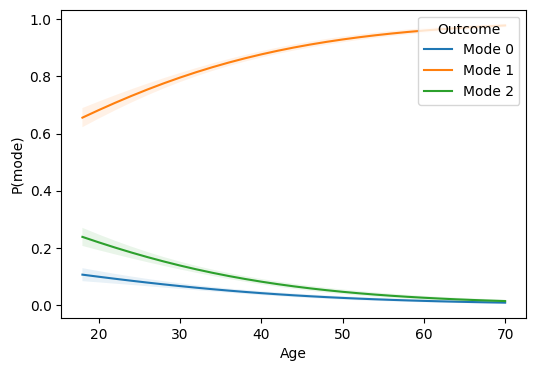

In [3]:
import matplotlib.pyplot as plt
import numpy as np

ages = list(range(18, 71, 2))
res = m.predict(atexog={"age": ages})

est = np.asarray(res.estimate)
se = np.asarray(res.std_error)
ci = np.asarray(res.conf_int())
n_scen, n_out = est.shape

rows = []
for i in range(n_scen):
    for j in range(n_out):
        rows.append({
            "age": ages[i],
            "outcome": j,
            "estimate": est[i, j],
            "ci_lower": ci[0, i, j],
            "ci_upper": ci[1, i, j],
        })
df_plot = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(6, 4))
for outcome, sub in df_plot.groupby("outcome"):
    ax.plot(sub["age"], sub["estimate"], label=f"Mode {outcome}")
    ax.fill_between(
        sub["age"], sub["ci_lower"], sub["ci_upper"], alpha=0.1
    )
ax.set(xlabel="Age", ylabel="P(mode)")
ax.legend(title="Outcome", loc="upper right")

In [4]:
ame = m.dydx("income")
print(ame.outcome(1).summary())

             Margins Result (delta, level=0.95)            
            estimate  std err    z  P>|z|  [95% Conf. Int.]
-----------------------------------------------------------
income (1)    0.0009   0.0001  inf  0.000    0.0007, 0.0011

n = 4000
κ: max=0.066
Delta-vs-sim disagreement: 4.644%


In [5]:
# Add a price variable to the data for illustration
df["price"] = rng.normal(10, 2, n)
fit_wtp = smf.mnlogit("mode ~ age + income + price", data=df).fit(disp=0)
m_wtp = Margins.linear_scale(fit_wtp, at="overall")

# WTP for one additional unit of income, in price units
wtp = m_wtp.wtp("income", "price")
print(wtp.summary())

/home/hunter/Workspace/pymargins/pymargins/margins/_session.py:898: UserWarning: Delta-method curvature κ=0.427 exceeds threshold (0.3, stacklevel=2); falling back to simulation.
  result_data = run_inference(


/home/hunter/Workspace/pymargins/pymargins/margins/_session.py:898: UserWarning: Delta-method curvature κ=0.346 exceeds threshold (0.3, stacklevel=2); falling back to simulation.
  result_data = run_inference(


             Margins Result (simulation, level=0.95)              
             estimate  std err  statistic  P>|z|  [95% Conf. Int.]
------------------------------------------------------------------
WTP(income)   -3.5790  20.7676    -3.5790  0.918   -4.4827, 4.1893
[1]           -6.3875  16.1152    -6.3875  0.943   -6.2535, 5.2193
[2]          -17.0035  13.7024   -17.0035  0.990   -3.4764, 4.0732

n = 4000
WARNING — Fallback triggered: kappa=0.427>threshold=0.3; kappa=0.346>threshold=0.3
κ: max=0.427


In [6]:
wtp_car = m_wtp.dydx("income").outcome(1)
price_car = m_wtp.dydx("price").outcome(1)
from pymargins._result._margins import compose_results
wtp_car_ratio = compose_results(
    [wtp_car, price_car],
    fn=lambda t: -t[0] / t[1],
    label="WTP_car(income)",
)
print(wtp_car_ratio.summary())

/home/hunter/Workspace/pymargins/pymargins/margins/_session.py:898: UserWarning: Delta-method curvature κ=0.427 exceeds threshold (0.3, stacklevel=2); falling back to simulation.
  result_data = run_inference(


/home/hunter/Workspace/pymargins/pymargins/margins/_session.py:898: UserWarning: Delta-method curvature κ=0.346 exceeds threshold (0.3, stacklevel=2); falling back to simulation.
  result_data = run_inference(


               Margins Result (simulation, level=0.95)                
                 estimate  std err  statistic  P>|z|  [95% Conf. Int.]
----------------------------------------------------------------------
WTP_car(income)   -6.3875  14.5420    -6.3875  0.946   -4.9769, 5.8939

n = 4000
WARNING — Fallback triggered: kappa=0.427>threshold=0.3; kappa=0.346>threshold=0.3
κ: max=0.427
